In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d
from scipy.integrate import quad

In [ ]:
omegam, chi2= np.load("chi2_values.npy")
posterior= np.exp(-0.5*chi2)

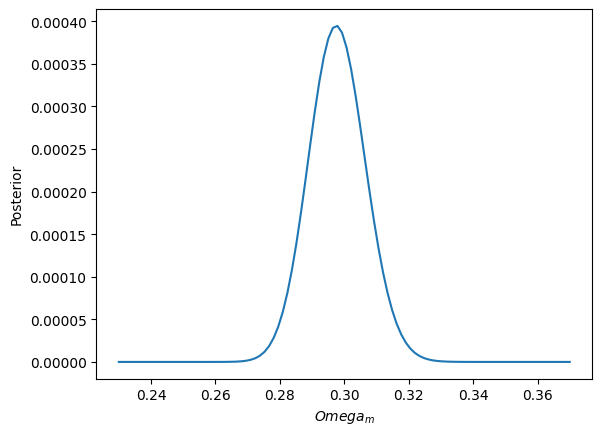

In [ ]:
plt.plot(omegam,posterior)
plt.xlabel(r"$Omega_m$")
plt.ylabel(r"P$Omega_m$")
plt.show()

In [ ]:
#questa è la distribuzione da cui io voglio campionare
#ci mancano ancora alcuni ingredienti ci manca la possibilità di calcolare f(x) per ogni valore di omegam

#interpolate posterior
from scipy.interpolate import interp1d
interp_posterior = interp1d(omegam, posterior, kind="cubic")

#ora ci manca x mu ma soprattutto q da cui dipenderà tutto
#la cosa necessaria di q è che copra tutta la funzione il rischio sennò è che il rapport sia più grande di uno
#e non campioni bene
#so già qual'è il picco della postirior trovando dov'è il minimo del chi2 per ora so dove si trova il picco a 4 per 10^-4 assumo che q(x) sia costante
#e che sia circa k = 1.01maxf(x)



In [ ]:
#definisco k
k= 1.01*np.max(posterior)

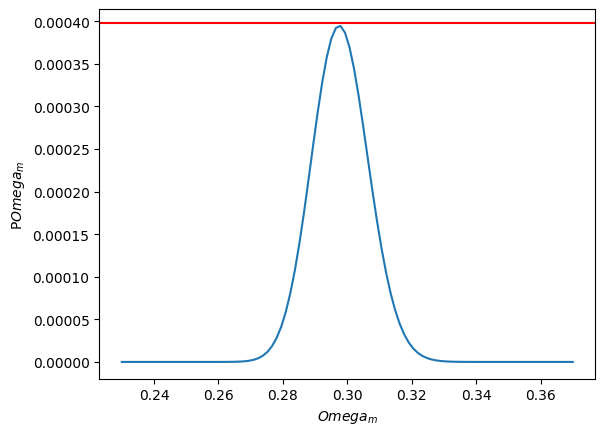

In [ ]:
plt.plot(omegam,posterior)
plt.axhline(y=k, color='r', linestyle='-')
plt.xlabel(r"$Omega_m$")
plt.ylabel(r"P$Omega_m$")
plt.show()

In [ ]:
#ora posso generare un num grande a piacere di omega m o scegliere quanti numeri volgio avere alla fine e fare il processo di
#reiezione finchè non ho la quantità di numeri desiderata il primo for secondo while
#genero questi due set di numeri random
n_attempts= 10000
omega_m_try= np.random.uniform(0.23, 0.37, n_attempts )
u= np.random.uniform(0,1,n_attempts)


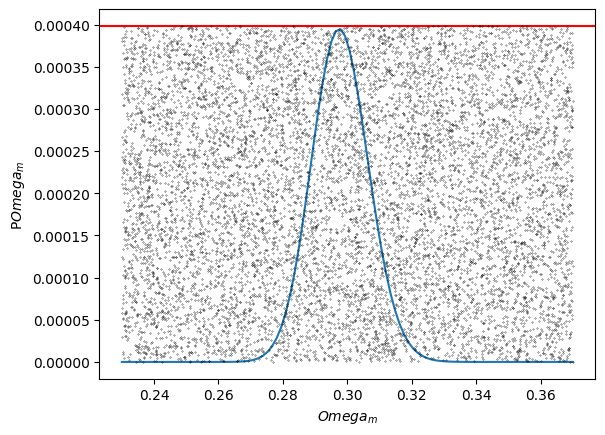

In [ ]:
plt.plot(omegam, posterior)
plt.axhline(y=k, color='r', linestyle='-')
plt.plot(omega_m_try, u*k, ".",ms="0.5", color="k")
plt.xlabel(r"$Omega_m$")
plt.ylabel(r"P$Omega_m$")
plt.show()

In [ ]:
#ora devo calcolare il rapporto e fare la condizione
ff= interp_posterior(omega_m_try)

In [ ]:
acc= ff> k*u
#confronta indice per indice restituisce una lista grande quanto ff e u

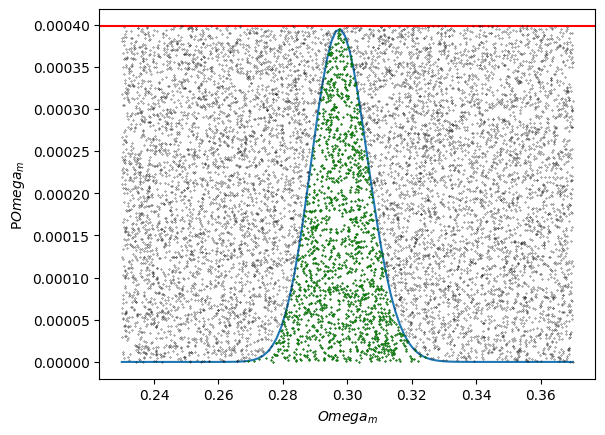

In [ ]:
plt.plot(omegam, posterior)
plt.axhline(y=k, color='r', linestyle='-')
plt.plot(omega_m_try, u*k, ".",ms="0.5", color="k")
plt.plot(omega_m_try[acc], u[acc]*k, ".",ms="1", color="g")
plt.xlabel(r"$Omega_m$")
plt.ylabel(r"P$Omega_m$")
plt.show()

questi metodi sono utili per gli integrali che non posso valutare in maniera deterministica confronto con i volumi di cui so calcolare l'area ci butto dei putni dentro e calcolo il rapporto tra le aree 1500/10000 è legato all'area sottesa dalla curva legato risp all'area del mio cubo

In [ ]:
sum(acc)
#mi dice per quanti oggetti vale questa condizione

np.int64(1571)

trovo che vale per il 15% degli oggetti

In [ ]:
#tutto dipende da come ho scelto q quindi cambio k e la ottengo
#scarto molti più punti stimatore baias ed errore l'errore dipende dal numero dei punti quindi ecco perché
#bisogna stare attenti mi serve per caratterizzare correttamente
#calcolo la media
omega_m_media= np.mean(omega_m_try[acc])
omega_m_std= np.std(omega_m_try[acc])
print("Omega_m:", omega_m_media , "+/-", omega_m_std)

Omega_m: 0.29812586610965974 +/- 0.008688067893042314
